Saving netflix_titles.csv to netflix_titles.csv
Dataset Shape:
(8807, 12)

Columns:
Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

Missing Values:
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

Data Types:
show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

Statistical Summary:
       show_id   type   title       director                cast  \
count     8807   8807    8807           6173                7982 

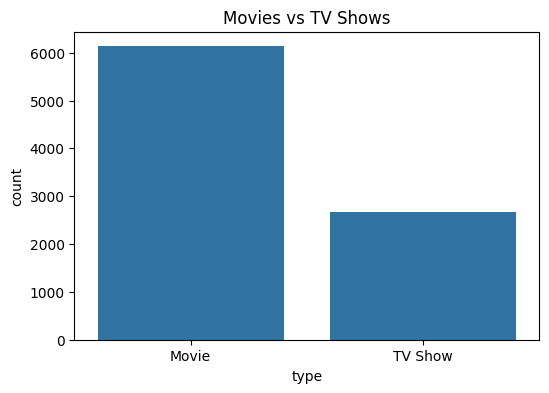

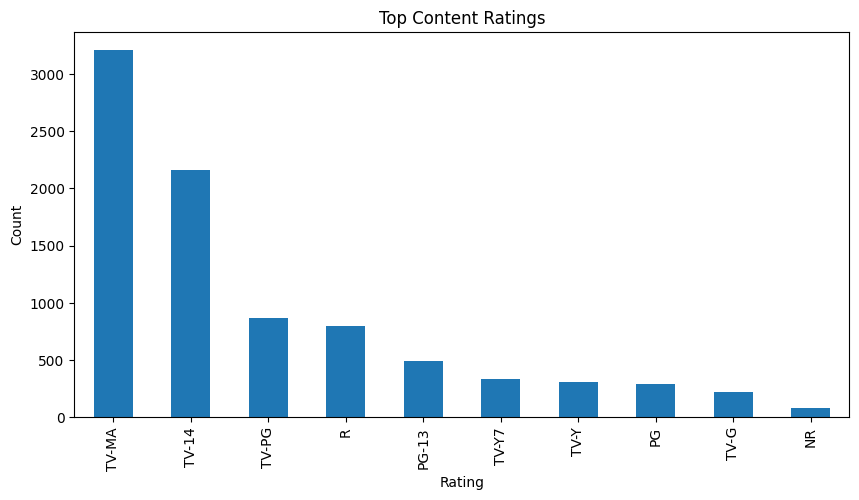

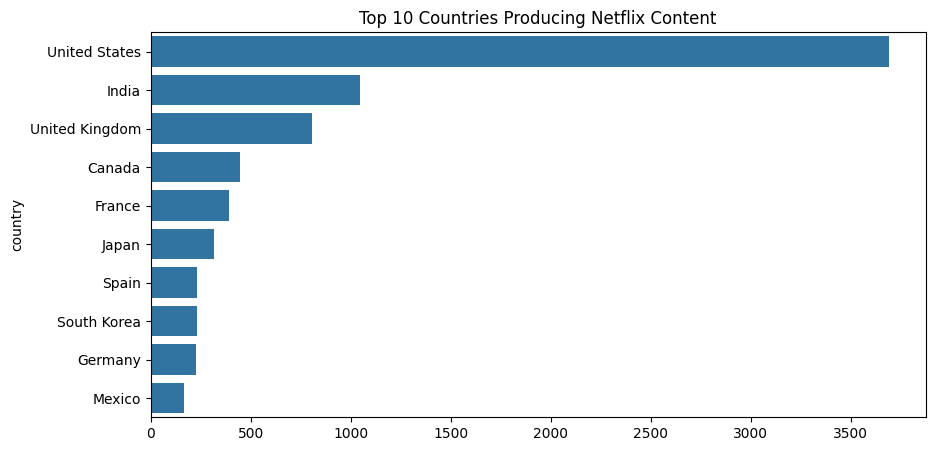

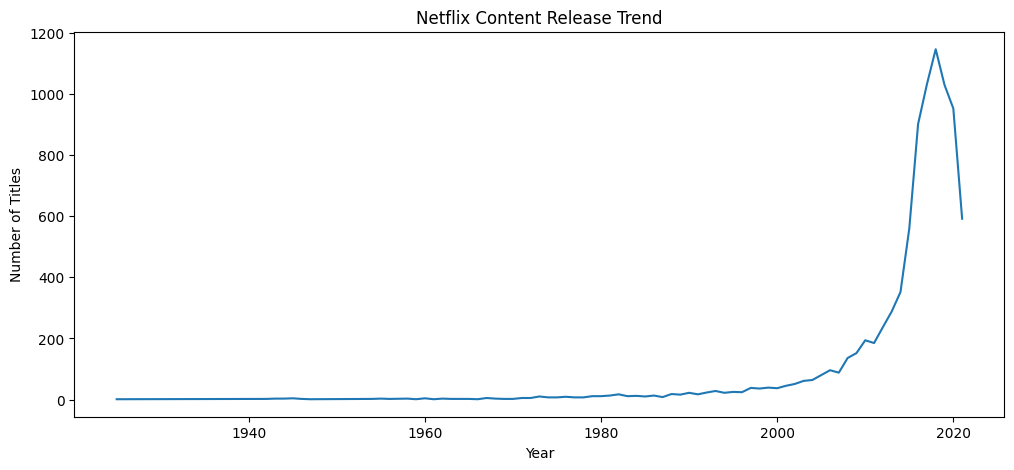

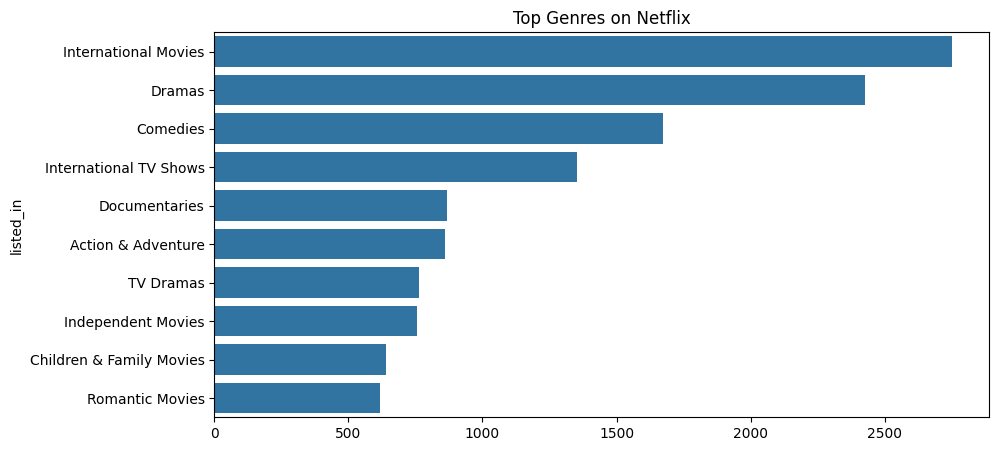

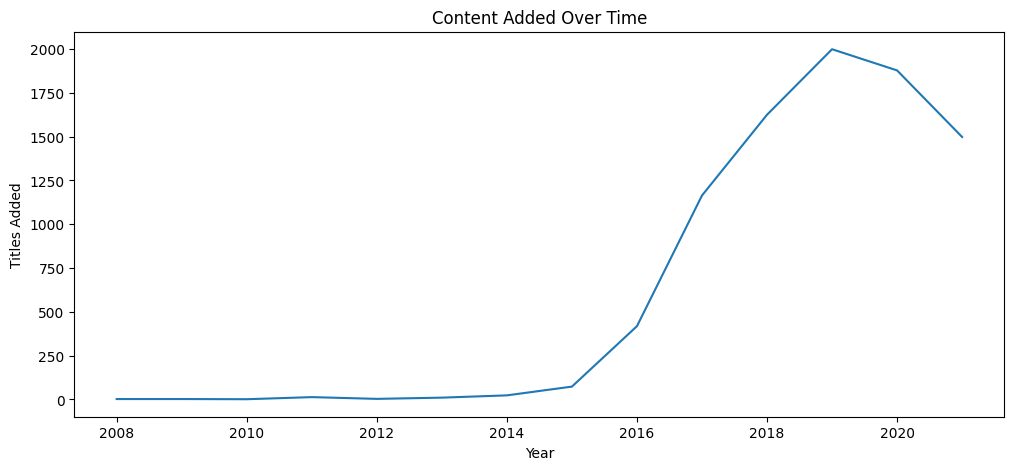

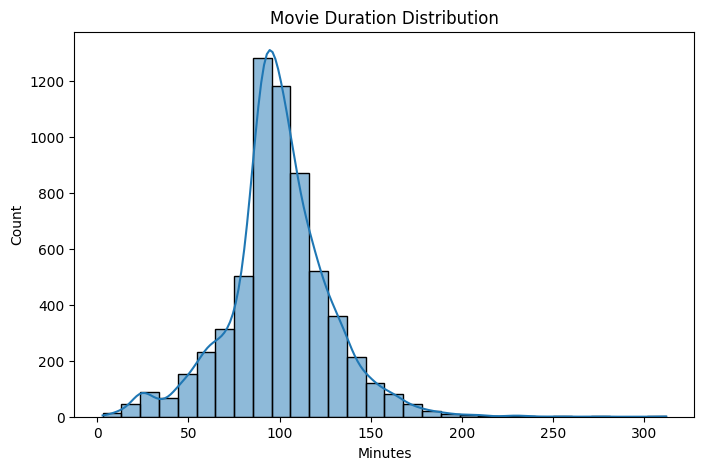

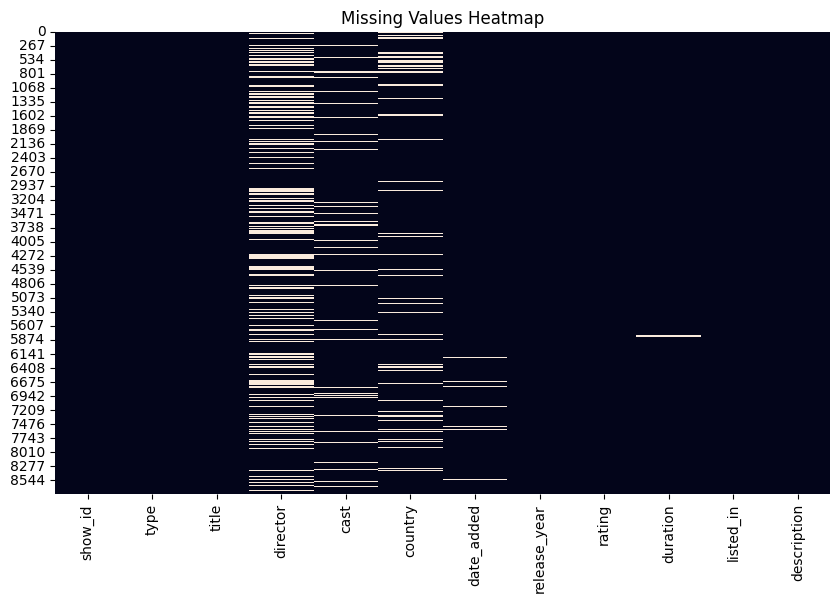

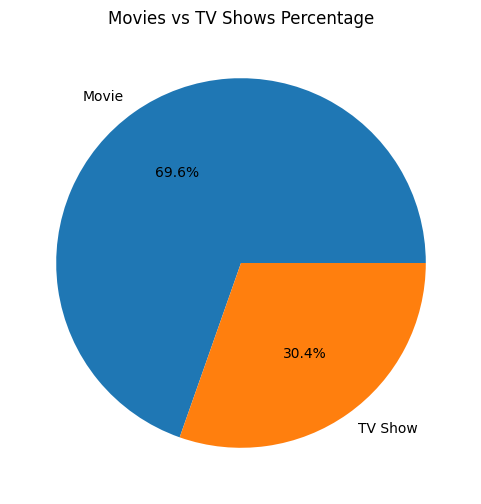


========== KEY INSIGHTS ==========

Total Titles:
8807

Movies:
6131

TV Shows:
2676

Most Common Genre:
International Movies

Top Producing Country:
United States

Most Common Rating:
TV-MA

Netflix_EDA_Cleaned.csv saved successfully!


In [2]:
# ==========================================
# NETFLIX EDA PROJECT
# ==========================================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

# Upload Dataset
uploaded = files.upload()

# Load Dataset
df = pd.read_csv("netflix_titles.csv")

# ==========================================
# DATASET OVERVIEW
# ==========================================

print("Dataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nData Types:")
print(df.dtypes)

print("\nStatistical Summary:")
print(df.describe(include='all'))

# ==========================================
# MOVIES VS TV SHOWS
# ==========================================

plt.figure(figsize=(6,4))
sns.countplot(x='type', data=df)
plt.title("Movies vs TV Shows")
plt.savefig("Movies_vs_TVShows.png")
plt.show()

# ==========================================
# TOP CONTENT RATINGS
# ==========================================

plt.figure(figsize=(10,5))

df['rating'].value_counts().head(10).plot(
    kind='bar'
)

plt.title("Top Content Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")

plt.savefig("Rating_Distribution.png")
plt.show()

# ==========================================
# TOP COUNTRIES
# ==========================================

countries = df['country'].dropna()

countries = countries.str.split(', ').explode()

top_countries = countries.value_counts().head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_countries.values,
    y=top_countries.index
)

plt.title("Top 10 Countries Producing Netflix Content")

plt.savefig("Top_Countries.png")

plt.show()

# ==========================================
# RELEASE YEAR TREND
# ==========================================

plt.figure(figsize=(12,5))

df['release_year'].value_counts().sort_index().plot()

plt.title("Netflix Content Release Trend")

plt.xlabel("Year")
plt.ylabel("Number of Titles")

plt.savefig("Release_Year_Trend.png")

plt.show()

# ==========================================
# TOP GENRES
# ==========================================

genres = df['listed_in'].str.split(', ').explode()

top_genres = genres.value_counts().head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_genres.values,
    y=top_genres.index
)

plt.title("Top Genres on Netflix")

plt.savefig("Top_Genres.png")

plt.show()

# ==========================================
# CONTENT ADDED OVER TIME
# ==========================================

df['date_added'] = pd.to_datetime(
    df['date_added'],
    errors='coerce'
)

content_growth = (
    df['date_added']
    .dt.year
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(12,5))

content_growth.plot()

plt.title("Content Added Over Time")

plt.xlabel("Year")
plt.ylabel("Titles Added")

plt.savefig("Content_Growth.png")

plt.show()

# ==========================================
# MOVIE DURATION ANALYSIS
# ==========================================

movies = df[df['type']=="Movie"].copy()

movies['duration'] = movies['duration'].str.replace(
    ' min',
    '',
    regex=False
)

movies['duration'] = pd.to_numeric(
    movies['duration'],
    errors='coerce'
)

plt.figure(figsize=(8,5))

sns.histplot(
    movies['duration'].dropna(),
    bins=30,
    kde=True
)

plt.title("Movie Duration Distribution")

plt.xlabel("Minutes")

plt.savefig("Movie_Duration.png")

plt.show()

# ==========================================
# MISSING VALUES HEATMAP
# ==========================================

plt.figure(figsize=(10,6))

sns.heatmap(
    df.isnull(),
    cbar=False
)

plt.title("Missing Values Heatmap")

plt.savefig("Missing_Values.png")

plt.show()

# ==========================================
# MOVIES VS TV SHOWS PIE CHART
# ==========================================

df['type'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6,6)
)

plt.title("Movies vs TV Shows Percentage")

plt.ylabel("")

plt.savefig("Movies_TVShows_PieChart.png")

plt.show()

# ==========================================
# KEY INSIGHTS
# ==========================================

print("\n========== KEY INSIGHTS ==========")

print("\nTotal Titles:")
print(len(df))

print("\nMovies:")
print(len(df[df['type']=="Movie"]))

print("\nTV Shows:")
print(len(df[df['type']=="TV Show"]))

print("\nMost Common Genre:")
print(genres.value_counts().idxmax())

print("\nTop Producing Country:")
print(countries.value_counts().idxmax())

print("\nMost Common Rating:")
print(df['rating'].value_counts().idxmax())

# ==========================================
# SAVE CLEANED DATASET
# ==========================================

df.to_csv(
    "Netflix_EDA_Cleaned.csv",
    index=False
)

print("\nNetflix_EDA_Cleaned.csv saved successfully!")

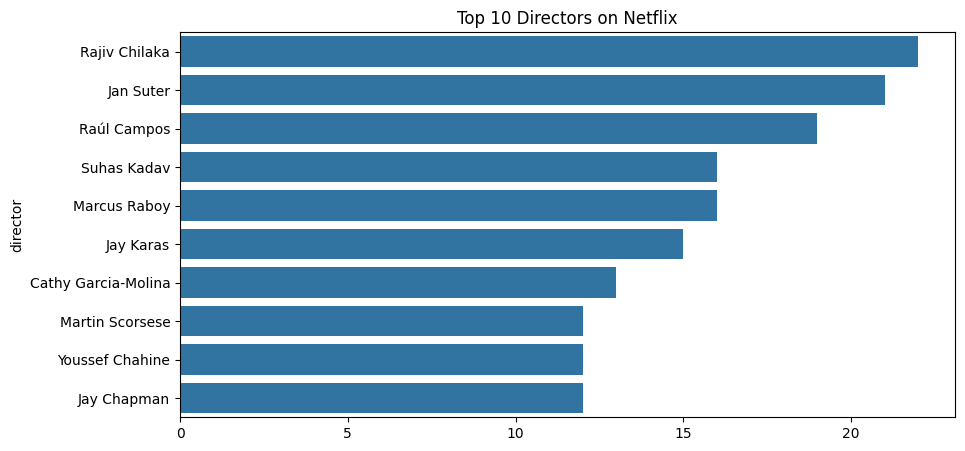

In [2]:
directors = df['director'].dropna().str.split(', ').explode()

top_directors = directors.value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_directors.values, y=top_directors.index)
plt.title("Top 10 Directors on Netflix")
plt.savefig("Top_Directors.png")
plt.show()

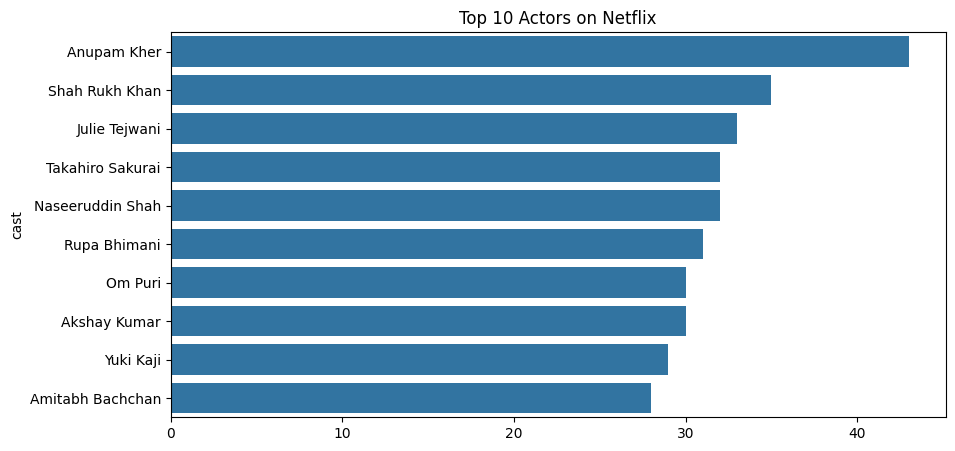

In [3]:
actors = df['cast'].dropna().str.split(', ').explode()

top_actors = actors.value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_actors.values, y=top_actors.index)
plt.title("Top 10 Actors on Netflix")
plt.savefig("Top_Actors.png")
plt.show()

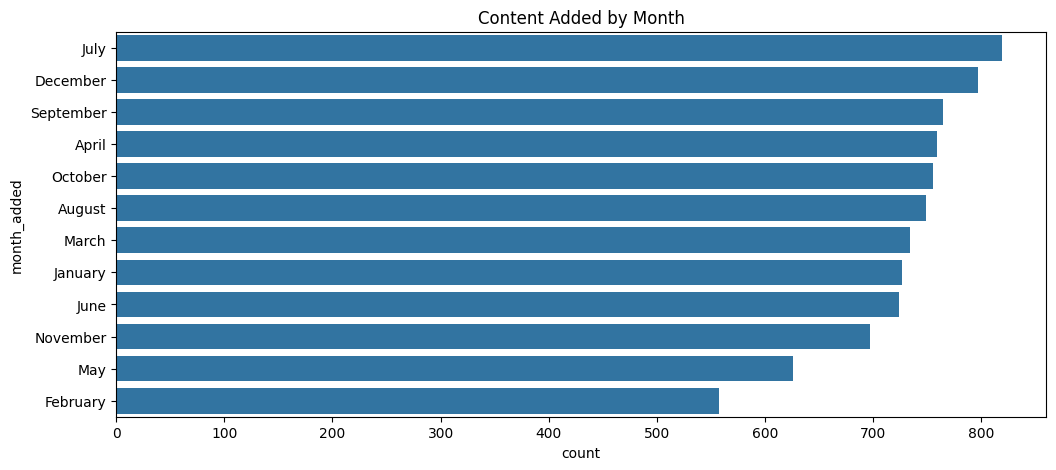

In [4]:
df['month_added'] = df['date_added'].dt.month_name()

plt.figure(figsize=(12,5))
sns.countplot(
    y='month_added',
    data=df,
    order=df['month_added'].value_counts().index
)

plt.title("Content Added by Month")
plt.savefig("Content_By_Month.png")
plt.show()

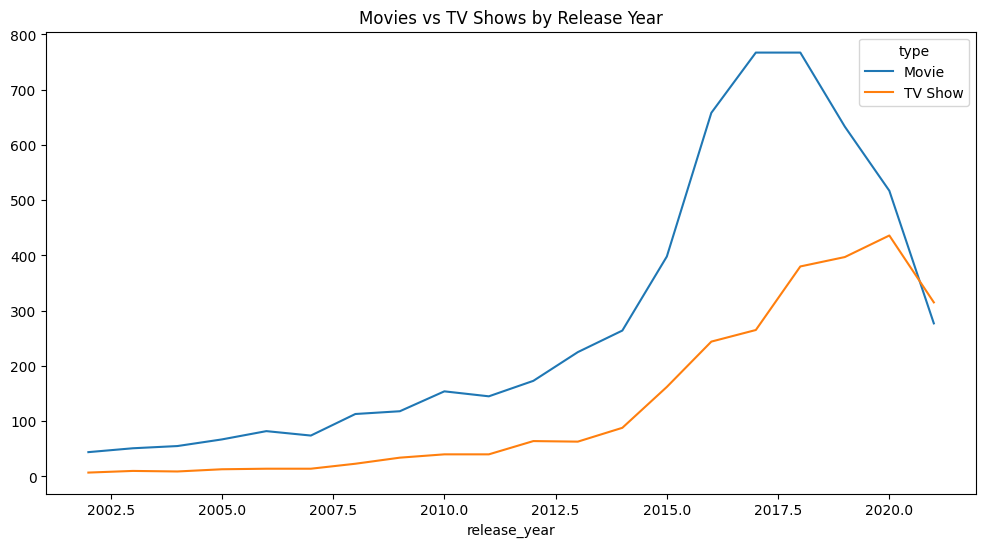

In [5]:
content_year = df.groupby(['release_year','type']).size().unstack()

content_year.tail(20).plot(figsize=(12,6))

plt.title("Movies vs TV Shows by Release Year")
plt.savefig("Movies_vs_TVShows_Yearly.png")
plt.show()

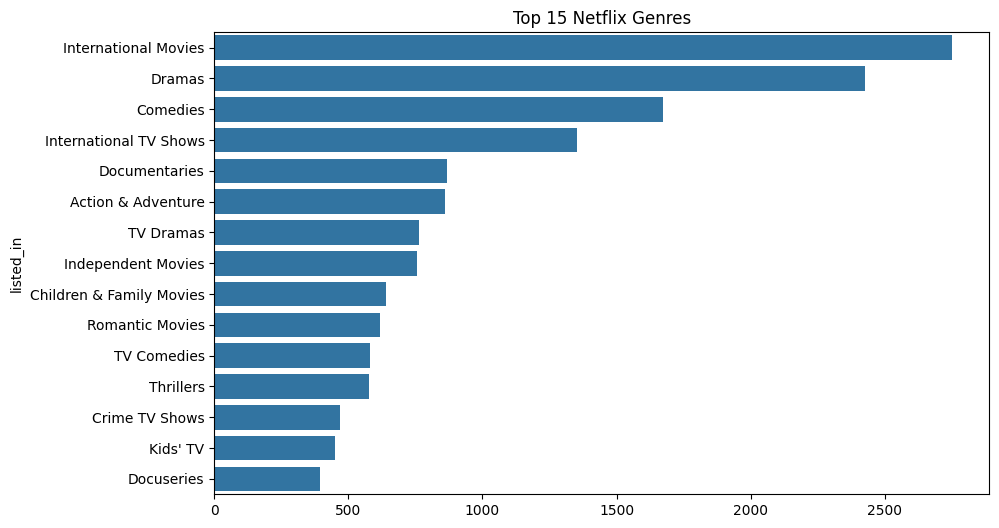

In [6]:
genres = df['listed_in'].str.split(', ').explode()

top15 = genres.value_counts().head(15)

plt.figure(figsize=(10,6))
sns.barplot(x=top15.values, y=top15.index)

plt.title("Top 15 Netflix Genres")
plt.savefig("Top15_Genres.png")
plt.show()

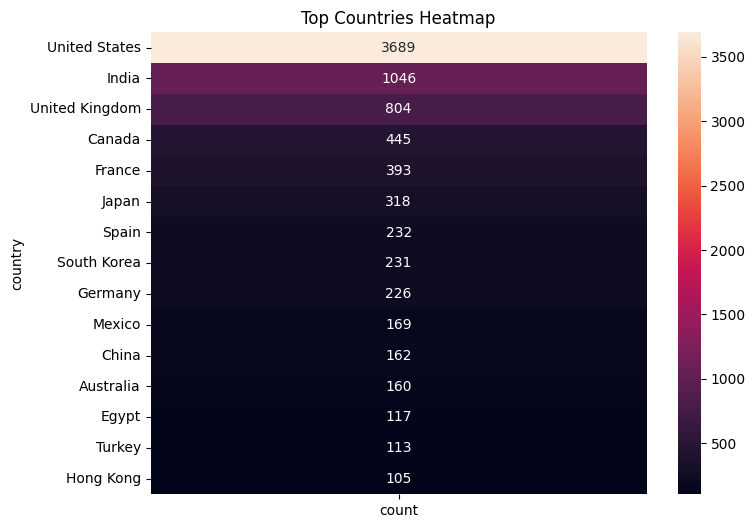

In [7]:
top_countries = countries.value_counts().head(15)

plt.figure(figsize=(8,6))

sns.heatmap(
    pd.DataFrame(top_countries),
    annot=True,
    fmt='g'
)

plt.title("Top Countries Heatmap")
plt.savefig("Country_Heatmap.png")
plt.show()

In [4]:
summary = pd.DataFrame({
    "Metric":[
        "Total Titles",
        "Movies",
        "TV Shows",
        "Countries",
        "Genres"
    ],
    "Value":[
        len(df),
        len(df[df['type']=="Movie"]),
        len(df[df['type']=="TV Show"]),
        countries.nunique(),
        genres.nunique()
    ]
})

print(summary)
summary.to_csv("Netflix_Summary.csv", index=False)

         Metric  Value
0  Total Titles   8807
1        Movies   6131
2      TV Shows   2676
3     Countries    127
4        Genres     42


In [ ]:
from google.colab import drive
drive.mount('/content/drive')